In [28]:
# data
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
import random

words = open('./data/names.txt', 'r').read().splitlines()
v = sorted(list(set(''.join(words))))
encode = { c:i+1 for i,c in enumerate(v) }
encode['.'] = 0
decode = { i:c for c,i in encode.items() }

context_length = 3
def gen_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * context_length;
        for c in w + '.':
            X.append(context)
            Y.append(encode[c])
            # print(''.join(decode[i] for i in context), '-->', decode[encode[c]])
            context = context[1:] + [encode[c]]
    X, Y = torch.tensor(X), torch.tensor(Y) # X:(N,C) Y:(N)
    return X, Y

random.seed(42)
random.shuffle(words)
n1, n2 = int(0.8*len(words)), int(0.9*len(words))
Xtr, Ytr = gen_dataset(words[:n1])
Xdev, Ydev = gen_dataset(words[n1:n2])
Xte, Yte = gen_dataset(words[n2:])

N= 182625 N_mini= 32
params 12297
loss_train 2.129643678665161
loss_val 2.152620553970337


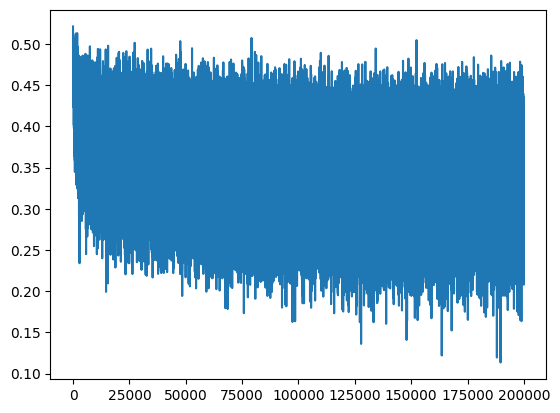

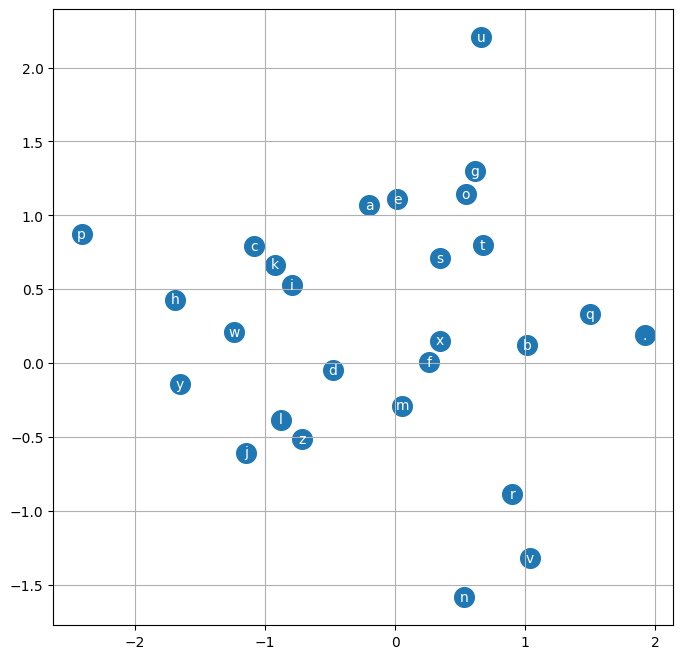

In [29]:
# model + training
g = torch.Generator().manual_seed(2147483647)
V, N, N_mini = len(encode.items()), Xtr.shape[0], 32
n_embd, n_hid = 10, 200
clXne = context_length * n_embd
print("N=", N, "N_mini=", N_mini)

# -model: https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf
C = torch.randn((V,n_embd), generator=g) # embed in R^2 (V:27,E:2)
# kaiming init: https://arxiv.org/pdf/1502.01852
W1, b1 = torch.randn((clXne,n_hid), generator=g) * (5/3)/(clXne**0.5), torch.randn(n_hid, generator=g) * 0.01
W2, b2 = torch.randn((n_hid,V), generator=g) * 0.01, torch.randn(V, generator=g) * 0
bngain, bnbias = torch.ones((1, n_hid)), torch.zeros((1, n_hid))

params = [C, W1, b1, W2, b2, bngain, bnbias]
print("params", sum(p.nelement() for p in params))
for p in params:
    p.requires_grad = True

losses = [] 
steps = []
for i in range(200000):
    # -forward
    ix_mini = torch.randint(0, N, (N_mini,))
    X_mini, Y_mini = Xtr[ix_mini], Ytr[ix_mini]

    embcat = C[X_mini].view(-1,clXne)
    h1preact =  embcat @ W1 + b1
    h1preact = bngain * (h1preact - h1preact.mean(0, keepdim=True)) / h1preact.std(0, keepdim=True) + bnbias
    h1 = torch.tanh(h1preact) # (-1=32,3,2)->(N:32,C*E:6) @ (C*E:6,100) = (32,100)
    logits = (h1 @ W2) + b2 # R (32,100) @ (100,27) + (1,27) = (32,27)
    loss = F.cross_entropy(logits, Y_mini) # fused kernels, numerical stability
    # print(loss.item())

    # -backward
    for p in params:
        p.grad = None
    loss.backward()
    # -update
    for p in params:
        p.data += -0.01 * p.grad

    steps.append(i)
    losses.append(loss.log10().item())

plt.plot(steps, losses)

embcat = C[Xtr].view(-1,clXne)
h1preact =  embcat @ W1 + b1
h1preact = bngain * (h1preact - h1preact.mean(0, keepdim=True)) / h1preact.std(0, keepdim=True) + bnbias
h1 = torch.tanh(h1preact) # (-1=32,3,2)->(N:32,C*E:6) @ (C*E:6,100) = (32,100)
logits = (h1 @ W2) + b2 # R (32,100) @ (100,27) + (1,27) = (32,27)
loss = F.cross_entropy(logits, Ytr) # fused kernels, numerical stability
print("loss_train", loss.item())

embcat = C[Xdev].view(-1,clXne)
h1preact =  embcat @ W1 + b1
h1preact = bngain * (h1preact - h1preact.mean(0, keepdim=True)) / h1preact.std(0, keepdim=True) + bnbias
h1 = torch.tanh(h1preact) # (-1=32,3,2)->(N:32,C*E:6) @ (C*E:6,100) = (32,100)
logits = (h1 @ W2) + b2 # R (32,100) @ (100,27) + (1,27) = (32,27)
loss = F.cross_entropy(logits, Ydev) # fused kernels, numerical stability
print("loss_val", loss.item())

plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), decode[i], ha="center", va="center", color="white")
plt.grid('minor')

In [30]:
# inference
i_terminal = 0
for _ in range(20):
    output = []
    context = [0] * context_length
    while True:
        emb = C[torch.tensor([context])]
        h1 = torch.tanh(emb.view(1,-1) @ W1 + b1) # (32,3,2)->(N:32,C*E:6) @ (C*E:6,100) = (32,100)
        logits = (h1 @ W2) + b2 # R (32,100) @ (100,27) + (1,27) = (32,27)
        y_hat = F.softmax(logits, dim=1)

        i = torch.multinomial(y_hat, num_samples=1, replacement=True, generator=g).item()
        context = context[1:] + [i]
        output.append(decode[i])
        if i == i_terminal:
            break
    print(''.join(output))

shregwllynd.
dha.
gizmmxeluphrszypmervikknislegramrlaserrles.
lzdussanr.
dith.
luth.
daklfornny.
fclandrack.
qtrwabbartividh.
thushroffth.
rangweno.
lunnclepp.
vimntarta.
gujyaqafrandis.
sumihandzcamndij.
nnyjengi.
luvik.
g.
kriktesdiannrytnnikyannefb.
rlfmrzhajlicollynn.
